# Excel em Figura de Tabelas

Este script funciona em duas etapas
1. Recebe uma pasta com um excel, onde cada aba tem uma tabela que deve ser convertido em PDF
2. Recebe uma pasta que contem PDFs de tabelas, onde as tabelas são convertidas em imagem

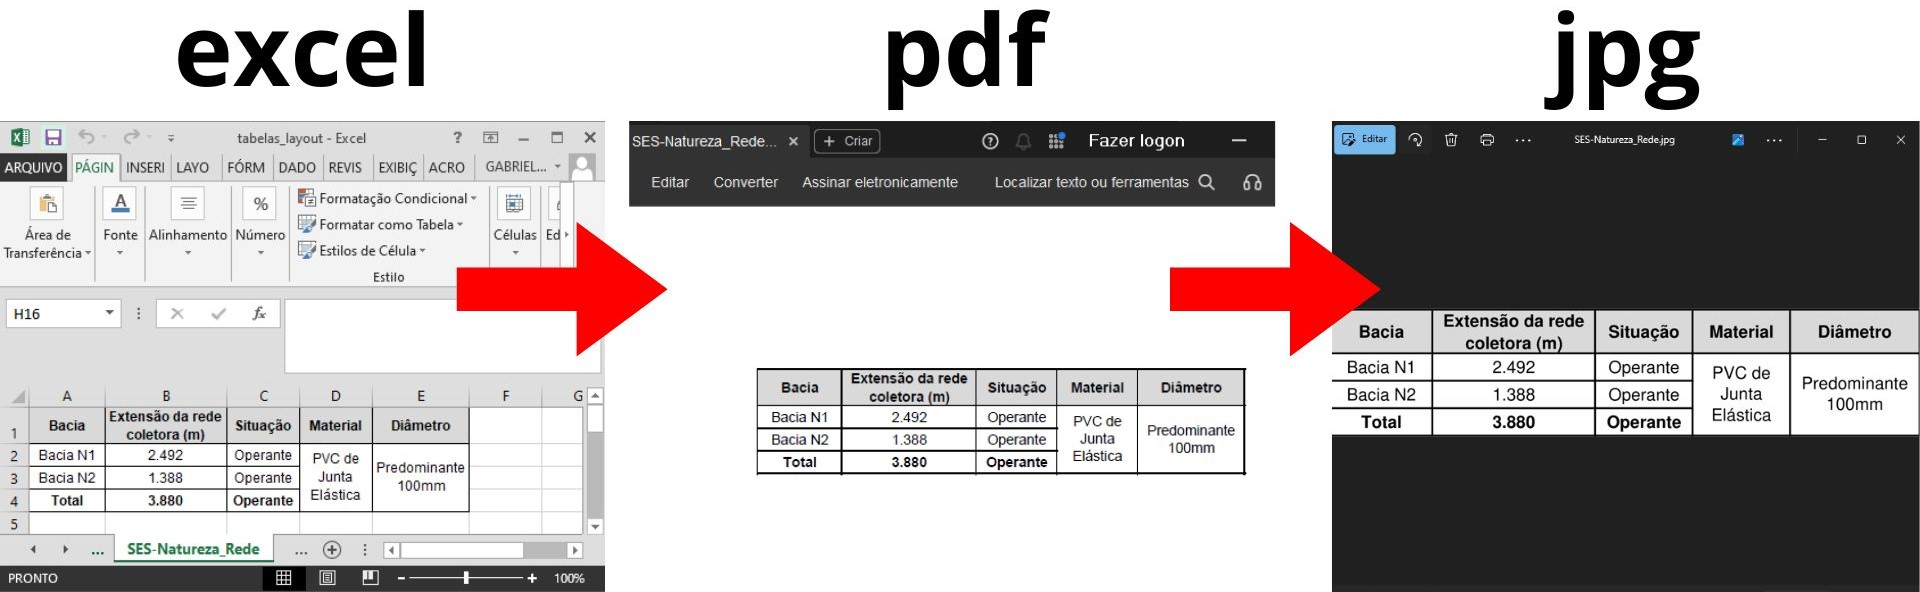

## Importação das bibliotecas

In [7]:
#!pip install pymupdf pillow opencv-python numpy
import os
import fitz  # PyMuPDF
from PIL import Image
import cv2
import numpy as np
import re                       # limpar nomes de arquivo (regex)
import win32com.client as win32 # controlar o Excel via automacao COM

## Funções

In [ ]:
# Constante do Excel: tipo de arquivo na exportacao (0 = PDF)
xlTypePDF = 0


def _sanitizar(nome):
    """
    Remove caracteres que nao sao permitidos em nome de arquivo
    (\\ / * ? : " < > |), trocando-os por "_".
    Evita erro ao salvar quando o nome da aba tem algum desses simbolos.
    """
    return re.sub(r'[\\/*?:"<>|]', "_", nome).strip()


def exportar_abas_para_pdf(excel_path, output_folder=None, ajustar_uma_pagina=True):
    """
    Exporta a tabela de cada aba (UsedRange) como PDF, nomeado com o nome da aba.
    Salva na pasta do proprio Excel se output_folder for None.
    Precisa do Excel instalado (Windows) e do pywin32.
    """
    # Garante caminho absoluto (evita ambiguidade de pasta relativa)
    excel_path = os.path.abspath(excel_path)

    # Se nao for informada pasta de saida, usa a mesma pasta onde esta o Excel
    if output_folder is None:
        output_folder = os.path.dirname(excel_path)
    # Cria a pasta de saida caso ela ainda nao exista
    os.makedirs(output_folder, exist_ok=True)

    # Abre uma instancia do Excel em segundo plano
    excel = win32.gencache.EnsureDispatch("Excel.Application")
    excel.Visible = False        # nao mostra a janela do Excel
    excel.DisplayAlerts = False  # silencia pop-ups (ex.: "deseja salvar?")

    wb = None
    try:
        # Abre o arquivo somente leitura (nao altera o original)
        wb = excel.Workbooks.Open(excel_path, ReadOnly=True)

        # Percorre TODAS as abas da planilha, uma por uma
        for ws in wb.Worksheets:
            # UsedRange = retangulo que contem todas as celulas com conteudo da aba
            rng = ws.UsedRange

            # Se a aba estiver vazia, pula pra proxima
            if rng is None or rng.Count == 0:
                print(f"[ignorada] '{ws.Name}' esta vazia.")
                continue

            # Configuracoes de impressao/pagina desta aba
            ps = ws.PageSetup

            # Define que so o intervalo com conteudo sera impresso
            # (rng.Address e algo como "$A$1:$E$7")
            ps.PrintArea = rng.Address

            # Encolhe a tabela pra caber em UMA unica pagina (largura e altura)
            if ajustar_uma_pagina:
                ps.Zoom = False          # desliga zoom fixo p/ usar o "fit to pages"
                ps.FitToPagesWide = 1    # tudo numa pagina na largura
                ps.FitToPagesTall = 1    # tudo numa pagina na altura

            # Margens enxutas (0.2 polegada) p/ a tabela ocupar mais espaco
            ps.LeftMargin = excel.InchesToPoints(0.2)
            ps.RightMargin = excel.InchesToPoints(0.2)
            ps.TopMargin = excel.InchesToPoints(0.2)
            ps.BottomMargin = excel.InchesToPoints(0.2)

            # Centraliza a tabela na pagina (horizontal e vertical)
            ps.CenterHorizontally = True
            ps.CenterVertically = True

            # Monta o caminho de saida: pasta + nome_da_aba + ".pdf"
            saida = os.path.join(output_folder, f"{_sanitizar(ws.Name)}.pdf")

            # Exporta a aba como PDF no caminho definido
            ws.ExportAsFixedFormat(xlTypePDF, saida)

            print(f"[ok] {ws.Name} -> {saida}")

    finally:
        # Bloco 'finally' roda sempre, mesmo se der erro no meio,
        # garantindo que o Excel seja fechado e nao fique aberto em memoria.
        if wb is not None:
            wb.Close(SaveChanges=False)  # fecha sem salvar (era so leitura)
        excel.Quit()                     # encerra a instancia do Excel

    print("Concluido.")

def crop_pdf_to_table(input_folder, output_folder, zoom=3.0, quality=100):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Percorrer todos os arquivos na pasta de entrada
    for file_name in os.listdir(input_folder):
        if file_name.lower().endswith('.pdf'):
            pdf_path = os.path.join(input_folder, file_name)
            pdf_document = fitz.open(pdf_path)

            # Processar cada página do PDF
            for page_num in range(len(pdf_document)):
                page = pdf_document[page_num]

                # Renderizar a página em alta resolução
                mat = fitz.Matrix(zoom, zoom)
                pix = page.get_pixmap(matrix=mat)

                # Converter a imagem da página para um formato compatível com o OpenCV
                img_cv = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
                if pix.n == 4:  # Transparência
                    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGBA2RGB)
                elif pix.n == 1:
                    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_GRAY2RGB)

                # Converter a imagem para escala de cinza
                gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

                # Aplicar limiarização para destacar os pixels pretos
                _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

                # Encontrar contornos
                contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                # Encontrar o maior contorno (assumindo que é a tabela)
                largest_contour = max(contours, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(largest_contour)

                # Recortar a imagem
                cropped_img = img_cv[y:y+h, x:x+w]

                # Converter a imagem de volta para PIL para salvar como JPG
                cropped_img_pil = Image.fromarray(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))

                # Salvar a imagem recortada como JPG com qualidade máxima e DPI alta
                output_file_name = f"{os.path.splitext(file_name)[0]}.jpg"
                output_path = os.path.join(output_folder, output_file_name)
                cropped_img_pil.save(output_path, "JPEG", quality=quality, dpi=(300, 300))

                print(f"{output_file_name} - {output_path}\n")

    print("Processing complete.")



## Código principal

In [ ]:
# Parte do código que transforma os Exceis (abas) em PDF
excel_path = r"C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas\tabelas_layout.xlsx"
exportar_abas_para_pdf(
    excel_path,
    output_folder=None,        # None = mesma pasta do Excel
    ajustar_uma_pagina=True,
)

# Parte do código que transforma os PDFs em figuras
input_folder = r'C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas' #onde tem os PDFs
output_folder = r"C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas" #onde vão sair as figuras
crop_pdf_to_table(input_folder, output_folder, zoom=4.0, quality=100)

[ok] SES-Central_EEE -> C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas\SES-Central_EEE.pdf
[ok] SES-Central_Rede -> C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas\SES-Central_Rede.pdf
[ok] SES-Central_ETE -> C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas\SES-Central_ETE.pdf
[ok] SES-Natureza_Rede -> C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas\SES-Natureza_Rede.pdf
[ok] SES-Natureza_ETE -> C:\Users\gabriel.coimbra\Desktop\Concórdia\PGs\tabelas\SES-Natureza_ETE.pdf
Concluido.
